In [1]:
!date

Mon Sep 14 07:50:11 PDT 2026


In [2]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

projdir = '/u/project/cluo/terencew/claude/project_ideas/pool_design'
MIN_CELLS = 20  # floor on assigned singlets before a donor is eligible to be the bottleneck

In [3]:
### load per-droplet scores and pool design metrics
scored = pd.read_csv(f'{projdir}/csv/ambisim/droplet_scores.csv', sep='\t')

design = pd.read_csv(f'{projdir}/csv/designs/nominated_pools_n8.tsv', sep='\t')
design['pool'] = design['universe'] + '__' + design['strategy'] + '__rep' + design['rep'].astype(str)
design = design.drop_duplicates('pool')[['pool', 'min_dist', 'mean_dist', 'kl_min', 'kl_mean']]
scored.head()

,pool,universe,strategy,rep,modality,barcode,is_true_singlet,called_singlet,correct,ambient_frac,ll_gap,called_donor,true_donor
0,AFR_only__adversarial_mindist__rep1,AFR_only,adversarial_mindist,1,gex,AAACAGCCAAACAACA,True,True,True,0.098320,15.04,HG03461,HG03461
1,AFR_only__adversarial_mindist__rep1,AFR_only,adversarial_mindist,1,gex,AAACAGCCAAACATAG,True,True,True,0.156914,10.97,NA18924,NA18924
2,AFR_only__adversarial_mindist__rep1,AFR_only,adversarial_mindist,1,gex,AAACAGCCAAACCCTA,True,False,False,0.391450,0.00,HG03520,HG03520
3,AFR_only__adversarial_mindist__rep1,AFR_only,adversarial_mindist,1,gex,AAACAGCCAAACCTAT,True,False,False,0.314493,0.00,NA18933,NA18933
4,AFR_only__adversarial_mindist__rep1,AFR_only,adversarial_mindist,1,gex,AAACAGCCAAACCTTG,True,True,True,0.184638,20.95,NA19150,NA19150


In [4]:
### per-ASSIGNED-donor mean LL-gap, mirrors ipynb/real_data/01h_bottleneck_donor.ipynb:
### group demuxlet's own singlet calls by the donor it assigned them to (not the true
### donor -- we don't get to use ground truth here either, to stay apples-to-apples
### with what the real-data notebook could do), regardless of whether that call is
### actually correct. This is the same quantity 01h calls 'mean_persnp_gap' per donor.
called = scored[scored['called_singlet']]
per_donor = called.groupby(['pool', 'universe', 'strategy', 'modality', 'called_donor']).agg(
    n_cells=('ll_gap', 'size'),
    mean_ll_gap=('ll_gap', 'mean'),
).reset_index()
per_donor.head()

,pool,universe,strategy,modality,called_donor,n_cells,mean_ll_gap
0,AFR_only__adversarial_mindist__rep1,AFR_only,adversarial_mindist,atac,HG01912,901,25.085771
1,AFR_only__adversarial_mindist__rep1,AFR_only,adversarial_mindist,atac,HG03439,955,27.431141
2,AFR_only__adversarial_mindist__rep1,AFR_only,adversarial_mindist,atac,HG03461,891,28.815724
3,AFR_only__adversarial_mindist__rep1,AFR_only,adversarial_mindist,atac,HG03520,929,25.649494
4,AFR_only__adversarial_mindist__rep1,AFR_only,adversarial_mindist,atac,NA18924,945,28.028370


In [5]:
per_donor['n_cells'].describe()

count    1408.000000
mean      892.477983
std        46.644563
min       681.000000
25%       859.000000
50%       897.000000
75%       932.000000
max       980.000000
Name: n_cells, dtype: float64

In [6]:
### drop donors with too few assigned cells before they're eligible to be flagged as
### the bottleneck -- a donor with e.g. 1-2 assigned cells can look spuriously "worst"
### from sampling noise alone (this was a real issue in the 01h precedent: one real
### donor there had n_cells=1)
n_before = len(per_donor)
per_donor_f = per_donor[per_donor['n_cells'] >= MIN_CELLS].copy()
print(f'{len(per_donor_f)} of {n_before} donor x pool x modality rows kept (>= {MIN_CELLS} cells)')

1408 of 1408 donor x pool x modality rows kept (>= 20 cells)


In [7]:
### identify the bottleneck donor per pool x modality: the assigned donor with the
### lowest mean LL-gap, i.e. the hardest-to-call donor in that specific pool
bottleneck = per_donor_f.loc[per_donor_f.groupby(['pool', 'modality'])['mean_ll_gap'].idxmin()]
bottleneck = bottleneck.rename(columns={'called_donor': 'bottleneck_donor',
                                         'mean_ll_gap': 'btl_ll_gap',
                                         'n_cells': 'btl_n_cells'})
bottleneck = bottleneck.merge(design, on='pool', how='left')
bottleneck.head()

,pool,universe,strategy,modality,bottleneck_donor,btl_n_cells,btl_ll_gap,min_dist,mean_dist,kl_min,kl_mean
0,AFR_only__adversarial_mindist__rep1,AFR_only,adversarial_mindist,atac,HG01912,901,25.085771,100.000000,103.623207,1.406993,1.504039
1,AFR_only__adversarial_mindist__rep1,AFR_only,adversarial_mindist,gex,HG01912,822,9.698929,100.000000,103.623207,1.406993,1.504039
2,AFR_only__adversarial_mindist__rep2,AFR_only,adversarial_mindist,atac,NA19146,897,25.775485,99.779755,102.815285,1.382161,1.473907
3,AFR_only__adversarial_mindist__rep2,AFR_only,adversarial_mindist,gex,NA19095,844,9.315640,99.779755,102.815285,1.382161,1.473907
4,AFR_only__greedy_maxkl__rep2,AFR_only,greedy_maxkl,atac,NA18489,949,25.106965,112.565536,119.123520,1.678527,1.935700


In [8]:
bottleneck.shape

(176, 11)

In [9]:
### THE apples-to-apples test: does min_dist predict the bottleneck (worst-donor)
### LL-gap better than mean_dist does? (min_dist and mean_dist are both matched in
### spirit to this outcome -- min_dist *is* this donor's distance to its closest
### neighbor in the pool, at least approximately, so this is the fair comparison
### that the pool-average metrics in 01b/01c could not make)
for modality in ['gex', 'atac']:
    sub = bottleneck[bottleneck['modality'] == modality]
    print(f'--- {modality} (n={len(sub)} pools) ---')
    for pred in ['min_dist', 'mean_dist', 'kl_min', 'kl_mean']:
        r, p = pearsonr(sub[pred], sub['btl_ll_gap'])
        print(f'  bottleneck LL-gap vs {pred:10s}: r={r:+.3f}  p={p:.3f}')

--- gex (n=88 pools) ---
  bottleneck LL-gap vs min_dist  : r=+0.732  p=0.000
  bottleneck LL-gap vs mean_dist : r=+0.593  p=0.000
  bottleneck LL-gap vs kl_min    : r=+0.760  p=0.000
  bottleneck LL-gap vs kl_mean   : r=+0.671  p=0.000
--- atac (n=88 pools) ---
  bottleneck LL-gap vs min_dist  : r=+0.765  p=0.000
  bottleneck LL-gap vs mean_dist : r=+0.561  p=0.000
  bottleneck LL-gap vs kl_min    : r=+0.778  p=0.000
  bottleneck LL-gap vs kl_mean   : r=+0.647  p=0.000


In [10]:
### for comparison: pool-AVERAGE LL-gap vs the same predictors (from 01b), so the
### min-vs-mean reversal (if any) is visible side by side in one place
pool_avg = called.groupby(['pool', 'universe', 'strategy', 'modality'])['ll_gap'].mean().reset_index()
pool_avg = pool_avg.merge(design, on='pool', how='left')
for modality in ['gex', 'atac']:
    sub = pool_avg[pool_avg['modality'] == modality]
    print(f'--- {modality} pool-average LL-gap (n={len(sub)} pools) ---')
    for pred in ['min_dist', 'mean_dist', 'kl_min', 'kl_mean']:
        r, p = pearsonr(sub[pred], sub['ll_gap'])
        print(f'  pool-average LL-gap vs {pred:10s}: r={r:+.3f}  p={p:.3f}')

--- gex pool-average LL-gap (n=88 pools) ---
  pool-average LL-gap vs min_dist  : r=+0.655  p=0.000
  pool-average LL-gap vs mean_dist : r=+0.729  p=0.000
  pool-average LL-gap vs kl_min    : r=+0.723  p=0.000
  pool-average LL-gap vs kl_mean   : r=+0.775  p=0.000
--- atac pool-average LL-gap (n=88 pools) ---
  pool-average LL-gap vs min_dist  : r=+0.728  p=0.000
  pool-average LL-gap vs mean_dist : r=+0.689  p=0.000
  pool-average LL-gap vs kl_min    : r=+0.787  p=0.000
  pool-average LL-gap vs kl_mean   : r=+0.764  p=0.000


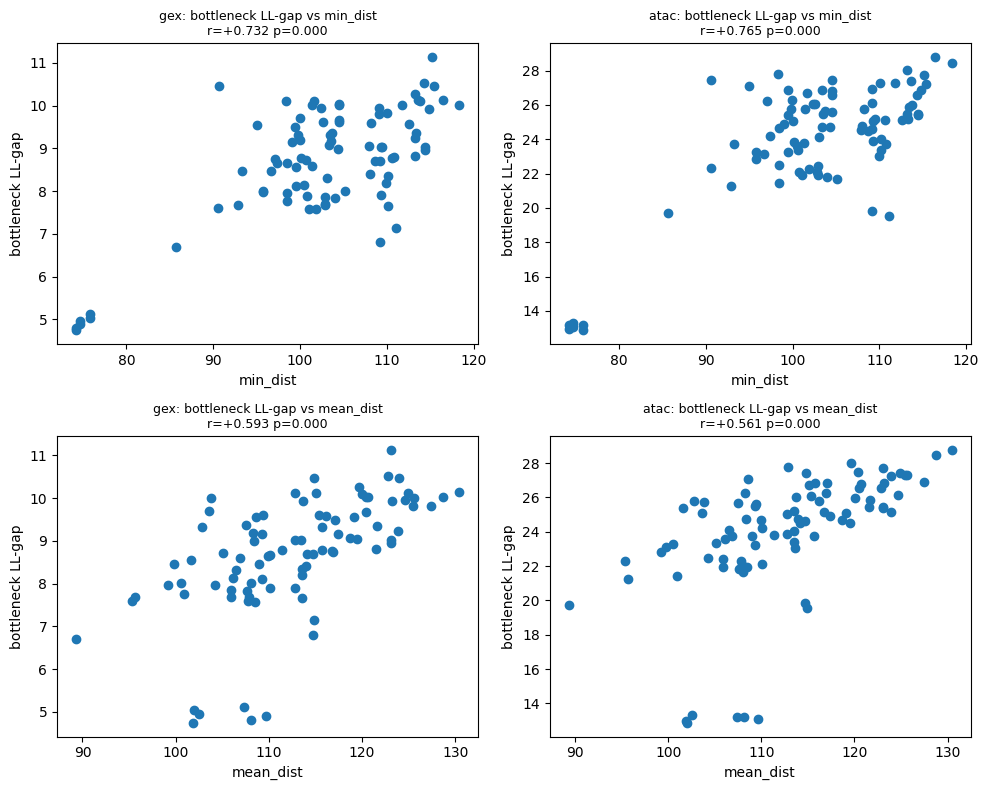

In [11]:
### plot: bottleneck LL-gap vs min_dist and vs mean_dist, side by side, per modality
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for col, modality in enumerate(['gex', 'atac']):
    sub = bottleneck[bottleneck['modality'] == modality]
    for row, pred in enumerate(['min_dist', 'mean_dist']):
        ax = axes[row, col]
        ax.scatter(sub[pred], sub['btl_ll_gap'])
        r, p = pearsonr(sub[pred], sub['btl_ll_gap'])
        ax.set_title(f'{modality}: bottleneck LL-gap vs {pred}\nr={r:+.3f} p={p:.3f}', fontsize=9)
        ax.set_xlabel(pred); ax.set_ylabel('bottleneck LL-gap')
plt.tight_layout()
plt.show()

In [12]:
### bonus (only possible because ambisim gives us ground truth, unlike real data):
### bottleneck TRUE-donor accuracy -- restrict to true singlets, group by true donor,
### take the pool's worst-accuracy true donor. Tests whether an accuracy-based
### bottleneck (rather than an LL-gap-based one) also tracks min_dist, since pool-
### AVERAGE accuracy showed ~no design signal in 01b.
sng_true = scored[scored['is_true_singlet']]
per_true_donor = sng_true.groupby(['pool', 'universe', 'strategy', 'modality', 'true_donor']).agg(
    n_cells=('correct', 'size'),
    donor_accuracy=('correct', 'mean'),
).reset_index()
per_true_donor_f = per_true_donor[per_true_donor['n_cells'] >= MIN_CELLS]

acc_bottleneck = per_true_donor_f.loc[per_true_donor_f.groupby(['pool', 'modality'])['donor_accuracy'].idxmin()]
acc_bottleneck = acc_bottleneck.merge(design, on='pool', how='left')

for modality in ['gex', 'atac']:
    sub = acc_bottleneck[acc_bottleneck['modality'] == modality]
    print(f'--- {modality} bottleneck TRUE-donor accuracy (n={len(sub)} pools) ---')
    for pred in ['min_dist', 'mean_dist']:
        r, p = pearsonr(sub[pred], sub['donor_accuracy'])
        print(f'  bottleneck accuracy vs {pred:10s}: r={r:+.3f}  p={p:.3f}')

--- gex bottleneck TRUE-donor accuracy (n=88 pools) ---
  bottleneck accuracy vs min_dist  : r=+0.175  p=0.102
  bottleneck accuracy vs mean_dist : r=+0.148  p=0.169
--- atac bottleneck TRUE-donor accuracy (n=88 pools) ---
  bottleneck accuracy vs min_dist  : r=+0.389  p=0.000
  bottleneck accuracy vs mean_dist : r=+0.415  p=0.000


In [13]:
### write out
outdir = f'{projdir}/csv/ambisim'
bottleneck.to_csv(f'{outdir}/bottleneck_donor_llgap.csv', sep='\t', index=False)
acc_bottleneck.to_csv(f'{outdir}/bottleneck_donor_accuracy.csv', sep='\t', index=False)

In [14]:
!date

Mon Sep 14 07:50:17 PDT 2026
